In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import pickle
from prep_files_for_altar import main
import h5py
from codes import CSIWrapper, AltarOutput

In [2]:
dirname = "in15"
multi, faults, datasets, trans = pickle.load(open(f"../results/inversion_results/{dirname}/inputs/csi.pickle", "rb"))
csi = CSIWrapper(multi, faults, datasets, trans)
# res = h5py.File(f"../results/inversion_results/{dirname}/outputs/step_final.h5", "r")

In [3]:
profiles, vertical_profiles = csi.gen_profiles(half_length=4.)

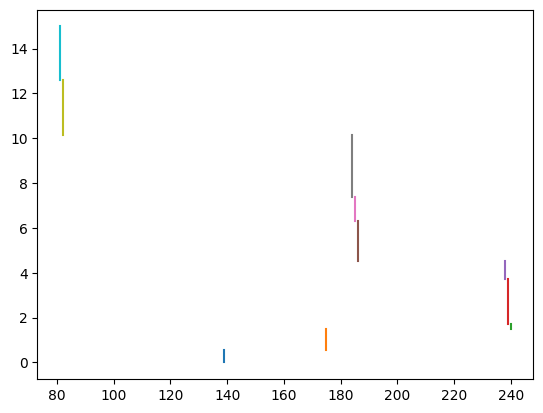

In [23]:
pid = 5
v = vertical_profiles[pid]
for p in v:
    plt.plot((p["patch_idx"], p["patch_idx"]), p["intersection"][:, 2])
plt.show()

In [5]:
from codes import OpticalData

optical = OpticalData(ew_filepath="../data/optical/EW_Ridgecrest_1m_utm_detrended.tif", ns_filepath="../data/optical/NS_Ridgecrest_1m_utm_detrended.tif")
optical = optical.clear_nan()
optical = optical.decimate(10)


Init OpticalData with {'ew_filepath': '../data/optical/EW_Ridgecrest_1m_utm_detrended.tif', 'ns_filepath': '../data/optical/NS_Ridgecrest_1m_utm_detrended.tif'}
Importing TIF files: ../data/optical/EW_Ridgecrest_1m_utm_detrended.tif ../data/optical/NS_Ridgecrest_1m_utm_detrended.tif
Imported EW data shape: (53626, 48648)
Imported NS data shape: (53626, 48648)

Clearing NaNs...
... cleared.
Decimating EW optical...
Decimating NS optical...
Decimated



In [ ]:
optical.plot(ns=False, profiles=profiles, profile_swathe_width=1000.)

In [6]:
profiles = optical.evaluate_profiles(profiles)

(200,)


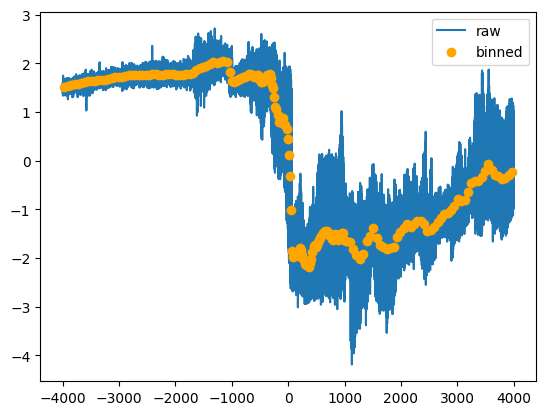

In [24]:
import copy
profile = copy.deepcopy(profiles[pid])

plt.plot(profile.xs, profile.displacements[1], label="raw")

profile = profile.bin_average(n_bins=200, n_near_fault_bins=100, near_fault_dist=1000.)
print(profile.xs.shape)
plt.scatter(profile.xs, profile.displacements[1], label="binned", color="orange", zorder=10)
plt.legend()

plt.show()

In [25]:
cd_estimator = profile.displacements[1,:50]
print(cd_estimator.shape)
x = np.arange(len(cd_estimator))
coeffs = np.polyfit(x, cd_estimator, 1)      # fit degree-1 polynomial
trend = np.polyval(coeffs, x)         # evaluate the trend line
detrended = cd_estimator - trend              # subtract it

std = np.std(detrended)
print(std)
data_covariance = std**2 * np.eye(profile.xs.size)

(50,)
0.047430051990973776


In [26]:
data = profile.displacements[1]
data -= np.mean(data)

c = np.argmax(data<0)
r = -data[c]/(data[c-1]-data[c])  # linear interpolation to find zero crossing
x0 = profile.xs[c] - r*(profile.xs[c]-profile.xs[c-1])

profile.xs -= x0

In [27]:
from codes import TwoDDzForwardModel, PatchTwoD, AltarOutput

altar = AltarOutput("../results/inversion_results/in15/outputs")

vd = [0., 500., 1000., 1500., 2750., 4000., 6000., 8000., 11000., 14000.]
model = TwoDDzForwardModel()
model.patches = [PatchTwoD(0., (vd[i]+vd[i+1])/2., vd[i+1]-vd[i]) for i in range(len(vd)-1)]
model.slips = np.zeros(len(model.patches))
model.xs = profile.xs

posteriors = []
for p in model.patches:
    z = p.z
    matching = filter(lambda x: x["intersection_top"]*1000 <= z and x["intersection_bot"]*1000 >= z, vertical_profiles[pid])
    match = next(matching)
    id = match["patch_idx"]
    posterior = altar.final["ParameterSets"]["strikeslipmain"][:, id]

    posteriors.append(posterior)

model.slips[3:] = np.median(posteriors[3:], axis=1)

In [28]:
from codes import UniformDist

# data = model.sol
# data_covariance = noise_lvl**2 * np.eye(xs.size)
# model.xs = xs

priors = [
    UniformDist("dz_halfwidth", 0., 1000.),
    UniformDist("modulus_ratio", 0.01, 0.9),
    UniformDist(f"slip0", -5., 0.),
    UniformDist(f"slip1", -10., 0.),
    UniformDist(f"slip2", -10., 0.)]

In [ ]:
from codes import HamiltonianInversion

inversion = HamiltonianInversion(model, priors, data, data_covariance)
inversion = inversion.run(draws=250, tune=100,chains=4)

Starting inversion...


/Users/hintont/Dev/projects/ridgecrest/.venv/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: ForwardOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/Users/hintont/Dev/projects/ridgecrest/.venv/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: ForwardOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads = node.op.pullback(inputs, node.outputs, new_output_grads)
/Users/hintont/Dev/projects/ridgecrest/.venv/lib/python3.14/site-packages/pytensor/gradient.py:1327: FutureWarning: ForwardOp should implement `pullback` instead of `L_op`/`grad`. Direct `L_op`/`grad` implementations are deprecated and will stop being called in a future version.
  input_grads 

Output()

In [ ]:
inversion.diagnostics()

In [ ]:
model.slips[:3] = [-0.16, -5.73, -0.03]
model.dz_half_width = 88.
model.modulus_ratio = 0.16
plt.plot(profile.xs, data, label="data")
plt.plot(profile.xs, model.run(profile.xs).sol, label="model")
plt.legend()
plt.show()